# Tutorial 4: Inferential Statistics
------------------------------------------------------------------------------------------------------------------

## Overview
The purpose of performing **inferential statistics** in Python for bioinformatics is to make data-driven conclusions about biological phenomena, often from limited samples, while accounting for uncertainty. 
 discoveries.
## Learning objectives

## Prerequisites
- You should be comfortable with Pandas and NumPy before using this tutorial
- A background in biostatistics is necessary, as this tutorial generally will assume you know why you would want to do particular statistical analysis
  
## Getting started
Please run the next code box to import the needed libraries, including
- Numpy, Pandas, Matplotlib
- Seaborn, statsmodels
- Scikit-learn

In [10]:
%pip install matplotlib
%pip install sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
print("All required packages have been installed")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All required packages have been installed


ERROR: Could not find a version that satisfies the requirement sklearn (from versions: none)
ERROR: No matching distribution found for sklearn


# Why do inferential statisics in python?

Bioinformatics typically involves large, complex datasets like gene expression levels, mutation rates, or protein interactions, and inferential statistics helps uncover patterns, relationships, and insights within this data. For example:

1. **Hypothesis Testing**: Determine whether observed differences (e.g., gene expression under two conditions) are statistically significant.
   - Example: Is a gene upregulated in diseased tissue compared to healthy tissue?
   
2. **Estimating Parameters**: Infer population characteristics, such as mutation frequencies or species diversity, from sample data.
   - Example: Estimating the prevalence of a mutation in a population from sequencing data.

3. **Correlations and Relationships**: Assess relationships between variables, such as gene expression levels and phenotypes, or identify co-expressed genes.
   - Example: Is the expression of a gene correlated with disease severity?

4. **Clustering and Classification**: Use statistical methods to group similar biological entities (e.g., clustering genes based on expression patterns) or classify data (e.g., distinguishing tumor subtypes).

Python, with libraries like **SciPy**, **statsmodels**, and **scikit-learn**, provides robust tools for inferential statistics, making it ideal for analyzing bioinformatics datasets. These tools help researchers efficiently handle large datasets, automate workflows, and visualize results, enabling reproducible and insightful biological discoveries.

## Loading SM Datasets 

Stats models comes with several datasets that can be loaded as a pandas Dataframe
Load a few different pandas datasets.

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  


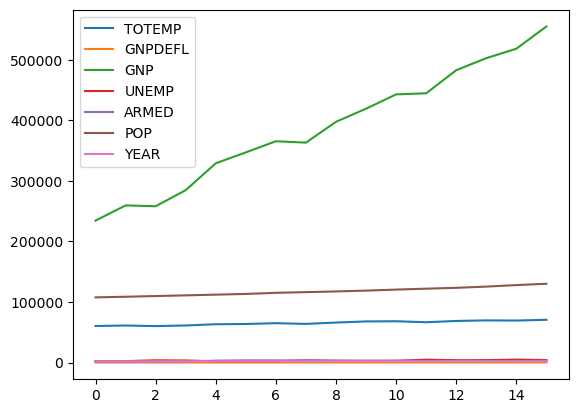

In [14]:
import pandas as pd
## get datasets
longley = sm.datasets.longley.load_pandas()
longley.data.plot()
# iris dataset
from sklearn.datasets import load_iris
irisData = load_iris()  # Load the Iris dataset
iris = pd.DataFrame(data=irisData.data, columns=irisData.feature_names) # Create a pandas DataFrame
iris['target'] = irisData.target # Add the target column
iris['species'] = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'}) # Map the target values to their corresponding species names
print(iris.head())  # Print the first 5 rows of the DataFrame

## Rand Health Insurance Data
rand_hi = sm.datasets.randhie.load_pandas().data
## Affairs data
affairs = sm.datasets.fair.load_pandas().data
## Election Studies Dataset
election_96 = sm.datasets.anes96.load_pandas().data

In [16]:
iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


MPGs across Transmissions

We might be interested in comparing MPG’s across different automatic versus manual transmissions.
We can first investigate the overall distribution of mpg…

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\jrcha\AppData\Local\Temp\ipykernel_13540\1851994015.py:2: SyntaxWarning: invalid escape sequence '\D'
  mtcars = pd.read_csv(".\Datasets\mtcars.csv")


36.32410282258065

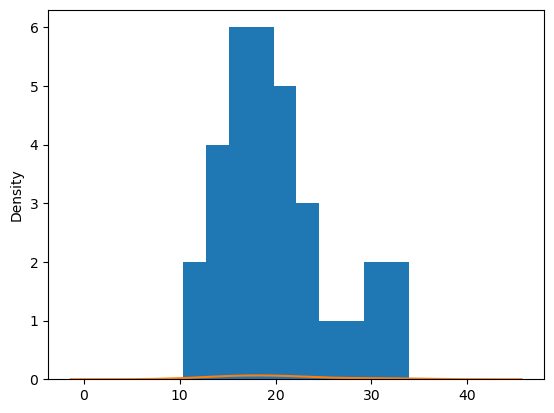

In [22]:
## Comparing Two Distributions
mtcars = pd.read_csv(".\Datasets\mtcars.csv")
mtcars.describe()

## Do mpgs differ between automatic and manual transmission?
mtcars.mpg.hist()
mtcars.mpg.plot(kind="kde")
mtcars.mpg.mean()
mtcars.mpg.std()
mtcars.mpg.var()

### Comparing Distributions

If we ask the question, "Do the miles per gallon (mpgs) differ by transmission (trans)?", what do we mean statistically by this? 

To start answering this question, how would you describe the distribution of mpgs, independent of trans? (hint below)

In [24]:
## Sufficient Statistics for the normal distribution
mtcars.mpg.mean()
mtcars.mpg.std()

6.026948052089105

### Normal Distribution / CLT

Perhaphs you have heard of the "central limit theorem." This theorem says that no matter what the underlying distribution of some values are, if we take a sample and then calculate the sample average, the distribution of those sample averages will be normal.
How do we estimate the underlying population mean?
We calculate the sample average and the sample variance!

###Comparing Two Distributions

When we compare two distributions, we are really comparing the sample average distributions..
Then, what does it mean to conclude two distributions are different?
That means we believe their underlying population means are different!
“Sure they are different, but are they statistically significantly different? “

### P-Values

Imagine you are flipping a coin. Will the next flip be heads or tails?
For one flip, it is easy: there is a 50% probability for each. But what if the
next three flips were all heads? The next 10? The next 50?
Would you still think there was an equal possibility for a head or tail 
on the next flip or would you conclude (infer) the coin was not actually fair?

Here's where the p-value comes in. The p-value gives us a threshold by which we make a
determination whether a given hypothesis is valid or not.

You could define a p-value this way:

“Given some hypothesis, what is the probability of getting this result (or one more extreme) assuming the null (or opposite) hypothesis is true?”

In other words, suppose you believe the coin in the last example is "not fair". What is the probability, given the null
hypothesis (the coin is "fair") that you would get 10 heads in a row?
You can calculate the p-value as 1/2^10 or 1/1024 or less than .1%. This means there is less than a .1% chance a fair coin will give you ten heads in a row.

What does that mean in this case. If you set your threshold of 5% and your p-value is less (in this case it is) than the null hypothesis is "false", meaning you can infer the coin that the opposite is true or that the coin is NOT fair. This is how inferential statistics works.
Now let's see how that applies to comparing two distributions.
Hypothesis: The distributions are different.
Null hypothesis: The distribtions are the same.


We can visually compare the two different distributions of data.
We might start to ask ourselves if they look that different…
Remember, the bigger the difference OR the more observations I have, the more certain I am of the result…

In [ ]:
## Compare MPGs across groups
sns.boxplot(x="am", y="mpg",data=mtcars)
mtcars.boxplot("mpg",by="am")
mtcars_group = mtcars.groupby(["am"])
mtcars_group.mpg.mean()
mtcars_group.mpg.hist()
mtcars_group.mpg.plot(kind="kde",legend=True)
mtcars_group.mpg.agg([np.mean,np.std])
mtcars_group['mpg'].agg([np.mean,np.std])

We can also use statistical tests such as the t-test or the Welch's t-test to generate
a p-value for comparison.

What if there are more than two distributions to test? For that we can use a more
sophisticated test such as ANOVA (assuming normal distribution) or the Kruskal-Wallis 
test (for medians).

We now are asking the question, are these population means unequal? 
Is at least one of the group means not equal to the others?

### Visually Explore The Distributions

Again, we can visually explore these distributions. 

In [ ]:
## mpg across cylinders
mtcars.boxplot("mpg",by="cyl")
mtcars_group = mtcars.groupby(["cyl"])
mtcars_group.mpg.plot(kind="kde",legend=True)
mtcars_group.mpg.agg([np.mean,np.std])
mtcars_group['mpg'].agg([np.mean,np.std])

### ANOVA

The formal statistical test for this comparison is an ANOVA

In [ ]:
## perform anova
mtcars_lm1=smf.ols('mpg~C(cyl)', data=mtcars) #Specify C for Categorical
sm.stats.anova_lm(mtcars_lm1.fit(), typ=2)
## get f statistic and p-value
sm.stats.anova_lm(mtcars_lm1.fit(), typ=2).ix[0,2:4]

### Comparing Distributions

Consider variable types. 
We just compared a continuous distributions with categorical distributions…

What about a continuous distribution with a continuous distribution?

We typically summarize continuous by continuous relationships as correlation. 
Simply put, do these variables move together? Is there a relationship between them? 

In [ ]:
## Correlation
## seaborn image 
sns.jointplot(x="mpg", y="disp", data=mtcars, kind="reg")
sns.jointplot(x="mpg", y="hp", data=mtcars, kind="reg")

### Calculate Correlation

We can calculate correlation as shown below
Do you know the difference between Kendall, Spearman, and Pearson (the default)?
Pearson is a linear correlation, the others are not. 

In [ ]:
## Examine the linear correlation between mpg and other values
?pd.DataFrame.corr
mtcars.loc[:,["mpg","disp","hp"]].corr()
mtcars.loc[:,["mpg","disp","hp"]].corr(method="kendall")
mtcars.loc[:,["mpg","disp","hp"]].corr(method="spearman")

## Calculate the covariance
mtcars.loc[:,["mpg","disp","hp"]].cov()


# Three Branches of Statistics

Python provides libraries for the 3 main branches of statistics:
- "Classical" or Frequentist (statsmodels)
- Bayesian (PyMC)
- "Machine Learning" (scikitlearn)

Machine learning is the subject of Module_3 of this course (Introduction to Python for Bioinformatics). 

# Linear Regression

We will focus, for now, on regular linear regression for multivariate statistics, but all lessons learned apply to other methods. 

What are the assumptions of linear regression?
- Independence
- Normality
- Linearity
- Homoscedasticity

Y ~ B0 + B1 * X1 + B2*X2

Linear Regression is the heart of modern frequentist statistics
Explore relationships between predictors and an outcome
There are different types of regression (see below).
Use regression to answer certain questions, but also understand your inputs.
  What type of data?
  What size of data?
  What are your intended outputs?


# Regression Types


- OLS Regression, or simple linear regression
- Multiple Linear Regression
    As a predictive analysis, multiple linear regression is used to explain the relationship between one 
    continuous dependent variable and two or more independent variables.

- Logistic Regression
    In statistics, logistic regression, or logit regression, or logit model is a regression model 
    where the dependent variable (DV) is categorical.

- Cox Time to Event Analysis
    Cox regression (or proportional hazards regression) is method for investigating the effect of several variables 
    upon the time a specified event takes to happen. 

- Mixed Effects (or hierarchical)
    Mixed effects logistic regression is used to model binary outcome variables, in which the log odds of 
    the outcomes are modeled as a linear combination of the predictor variables when data are clustered 
    or there are both fixed and random effects. 

- Repeated Measures (time series)

- Non-parametric
    Nonparametric statistics are statistics not based on parameterized families (mean, variance, etc.) 
    of probability distributions.


### The General Regression Strategy

Collect appropriate data
Identify Outcomes / predictors
Investigate "shape" of data
Consider appropriate functional form
Apply prior knowledge
Select "best" model and variables
Check model for validity (residuals, etc)
Apply model
Predict new results

### OLS Regression

"Basic" regression
Easy to learn conceptually, applies to other
Outcome is a continuous variable
Predicting weight
Predicting monetary values
Predicting Lab tests
What are the assumptions of ordinary linear regression?

Formula: y = xb + e or y = b0 + b1x + e
x – some input
b – some vector of parameters
e – some error
B0 – constant/y-intercept
B1 - slope

For OLS regression, we have to make some assumptions (this is key):
Normality
Independence
Linearity
Homoscedasticity
What's all this about assumptions? If I get numbers out it worked, right?


Try to write out the regression equation that is being fit below. 
We are regressing am on mpg. You are looking for b0, b1, assume e = 0.

In [ ]:
## Linear Regression with One predictor
## Fit regression model
mtcars["constant"] = 1
X = mtcars.loc[:,["constant","am"]]
Y = mtcars.mpg
mod1res = sm.OLS(Y, X).fit()

# Model Summary Results

Use Python to inspect the results object. 

In [ ]:
## Inspect the results
print(mod1res.summary())
print(mod1res.summary2()) ## different format

Let's examine the model for some specific traits.
    Use dir(mod1res) to see all the methods.

In [ ]:
## Get AIC for model
mod1res.aic
## Get r-squared
mod1res.rsquared
## r-squared penalized for the number of parameters
mod1res.rsquared_adj

## Mean squared error...?
1 - mod1res.mse_resid/mod1res.mse_total
mod1res.mse_model

We can pull out the residuals.
    Do you know what those are? 

In [ ]:
## View residuals
mod1res.resid
mod1res.resid_pearson
## View Predicted Values
mod1res.predict()

## Get the influence of each value? DBETAS?
mod1res.get_influence()

## View available model attributes
dir(mod1res)

We can request some automatic plots using stats models graphics.

In [ ]:
## Goodness of fit
## Find outlier observations
mod1res.outlier_test()

## Goodness of fit plots
sm.graphics.plot_regress_exog(mod1res, "am")

Regression with Categorical
We can fit a regression with a categorical predictor as well. 
(Note the add_constant function)

In [ ]:
## Linear Regression with Categorical predictors
## mpg and cylinder
## Fit regression model
mtcars["constant"] = 1
X = mtcars.loc[:,["constant","cyl"]]
Y = mtcars.mpg
mod2res = sm.OLS(Y, X).fit()
print(mod2res.summary())
## Alternatively:
X = sm.add_constant(mtcars.cyl)

## Dummy Coding Variables

OLS deals in continuous interpretations. What about categorical variables?
    You can fix this by adding a dummy variable. ("One hot coding" as we learned in the [Numpy tutorial](./Submodule_2_Tutorial1_NumPy.ipynb)

In [ ]:
## We need to dummy code the categorical variable
mtcars['cyl_6'] = 0
mtcars.loc[mtcars.cyl == 6,'cyl_6'] = 1
mtcars['cyl_8'] = 0
mtcars.loc[mtcars.cyl == 8,'cyl_8'] = 1
## Rerun the model with more parameters
X = mtcars.loc[:,["constant","cyl_6","cyl_8"]]
Y = mtcars.mpg
mod3res = sm.OLS(Y, X).fit()
print(mod3res.summary())

A nifty shortcut to setting this problem up

The patsy package allows us to use a formula style interface.
This is included with statsmodels, but we need to use smf instead of sm (check the original imports)

In [ ]:
## Is there an easier way to set up these matrices?!?
## We can use the formula interface, patsy package
## Formula interface included with statsmodels
## Fit same model
mod4res = smf.ols('mpg ~ C(cyl)', data=mtcars).fit()
mod4res.summary() 

Multiple Linear Regression
    We can add multiple parameters. 

In [ ]:
## Linear regression with multiple predictors

mod5res = smf.ols('mpg ~ C(cyl) + disp', data=mtcars).fit()
mod5res.summary() 

mod6res = smf.ols('mpg ~ C(cyl) + disp + am', data=mtcars).fit()
mod6res.summary() 

## Does AM add anything?
sm.stats.anova_lm(mod6res, typ=2)


# Comparing Models

We can compare model fits with AIC 
    likelihood based statistic penalized for # of parameters

In [ ]:
## comparing model fits - AIC
print("model-6 AIC: ", mod6res.aic)
print("model-5 AIC: ", mod5res.aic)
print("model-4 AIC: ", mod4res.aic)

## Sum of Squared Errors

We can also use R-squared, which can be interpreted as the proportion of variance explained by the model. 
If r-squared goes up, is the model better?
Not necessarily! We need to adjust it (r2)

In [ ]:
## Compare Model Fits - r-squared
print("mod6res.rsquared: ", mod6res.rsquared)
print("mod5res.rsquared: ", mod5res.rsquared)
print("mod4res.rsquared: ", mod4res.rsquared)

## Compare Model Fits - r-squared adjusted
print("mod6res.rsquared_adj: ", mod6res.rsquared_adj)
print("mod5res.rsquared_adj: ", mod5res.rsquared_adj)
print("mod4res.rsquared_adj: ", mod4res.rsquared_adj)

## Likelihood Ratio Test

We can use a LRT for models that are “nested”
Meaning one model can be recovered from the other by deleting parameters…
If they are not nested, we must use AIC

In [ ]:
## Compare Model fits - likelihood
print("model-6 LLF: ", mod6res.llf)
print("model-5 LLF: ", mod5res.llf)

## Likelihood ratio test
sm.stats.anova_lm(mod5res,mod6res)

Regression Diagnostics

The Seaborn package allows us to visualize lowess curves and reveals potential non-linear relationships.

In [ ]:
## Seaborn regression diagnostics: non-linear relationships
sns.lmplot(x="disp", y="mpg", data=mtcars, lowess=True)
mtcars.plot.scatter(x='mpg',y='disp')

The statsmodels graphics package has several plot methods that will assist with poor model fit identification. 
Review these on your screen.

In [ ]:
## Examine the goodness of fit plots 
sm.graphics.plot_fit(mod5res,exog_idx=3)
sm.graphics.plot_regress_exog(mod5res,exog_idx=3)
sm.graphics.influence_plot(mod5res)
sm.graphics.plot_leverage_resid2(mod5res)

### Scoring New Data

We are often interested in making predictions using a model, or “scoring” new data. 
We can easily do this with stats models
We must first create a new dataset to score. 

In [ ]:
## Scoring Data
## create dataframe
mtcars.cyl.unique()
mtcars.disp.describe()
new_dat = pd.DataFrame({'cyl':mtcars.cyl.unique(),
 'disp':(80,100,120)})
## Predict the new values
mod5res.predict(new_dat)

### Polynomial Regression

Displacement appeared to have a non-linear relationship with mpg. Perhaps we should fit a quadratic term? 

In [ ]:
## Linear regression with polynomials
## add disp squared
mtcars['disp_2'] = mtcars.disp **2
mod7res = smf.ols('mpg ~ disp', data=mtcars).fit()
mod7res.summary() 
mod8res = smf.ols('mpg ~ disp + disp_2', data=mtcars).fit()
mod8res.summary() 
## Did this improve the model fit?
sm.stats.anova_lm(mod8res, typ=2)

### Using Formulas

We can use formulas when we know or have hypothesized the relationship. 
This has several advantages
When we score data, it will automatically be transformed.
No need to create intermediate columns.

In [ ]:
## We can rewrite this with formulas...
smf.ols('mpg ~ disp + disp_2', data=mtcars).fit().summary()
smf.ols('mpg ~ disp + np.square(disp)', data=mtcars).fit().summary()
smf.ols('mpg ~ disp + np.power(disp,2)', data=mtcars).fit().summary()

## Other Functions

We can try any other vectorized functions using the formula interface as well. 
We may need to capture the non-linearity with expressions other than polynomials!

In [ ]:
## Linear regression with other functions (log)
mod10res = smf.ols('mpg ~ np.log(disp)', data=mtcars).fit()
mod10res.summary()


### Patsy Formulas

We mentioned that the Patsy package enables the formula interface.
We can use Patsy alone to generate the X matrices, then pass them into the object
We will do this in the machine learning module as there is no support for formulas natively.

In [ ]:
## Using Patsy alone to generate matrices
from patsy import dmatrices
from patsy import dmatrix
f = 'mpg ~ disp + C(cyl)'
y,X = dmatrices(f, mtcars)
y
X
y,X = dmatrices(f, mtcars,return_type='dataframe')

We can now fit the model with our X and Y matrices
Patsy has other useful functions including center and standardize

In [ ]:
## notice we used OLS instead of ols...
mod11res = smf.OLS(y,X).fit()
mod11res.summary()

### Other useful patsy functions
## Center and standardize
dmatrix("disp + center(disp) + standardize(disp)", mtcars)

### Splines

We can also use Patsy to fit splines, or flexible fit curves to capture non-linearity.
There is support for basis splines, cubic splines, and cyclic cubic splines. 

In [ ]:
## Linear regression with Spline terms
## basis splines
dmatrix("bs(disp,df=4)", mtcars)

## cubic splines
dmatrix("cr(disp,df=4)", mtcars)

## cyclic cubic splines
dmatrix("cc(disp,df=4)", mtcars)

## Interactions

What is an interaction in linear modeling?
    It's when one variable depends upon another variable.
    The dependency can be slight or great.

In [ ]:
## Linear regression with interactions
## make interaction plot seaborn cyl, mpg, hp
sns.lmplot(x="hp", y="mpg", hue="cyl", data=mtcars);
mod12 = smf.ols('mpg ~ hp + C(cyl)', 
        data=mtcars).fit()
sm.stats.anova_lm(mod12, typ=2)

### Interactions in Models

We indicate interactions in models with the : (colon sign)
We can also use  *  as a shortcut to include the interaction and the lower terms:
x1*x2 -> expands to: x1 + x2 + x1:x2

In [ ]:
## Test for an interaction here
mod13 = smf.ols('mpg ~ hp + C(cyl) + hp:C(cyl)', 
        data=mtcars).fit()
sm.stats.anova_lm(mod13, typ=2)

# Conclusions

After this tutorial, you will be able to do several things.

The next module, [Data Reduction](./Submodule2_Tutorial5_DataReduction.ipynb)

## Clean up
Remember to shut down your Notebook compute instance when you are done for the day to avoid unnecessary charges. You can do this on the ml.azure.com toolbar, by clicking on compute.